In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import pingouin as pg
import numpy as np
import sklearn as sk
from scipy.stats import boxcox
from scipy.stats import rankdata


**Loading of data**


In [ ]:
# Load data
df = pd.read_csv("Output_extraction/ai_grading_final_v3.csv")

df["prompt_type"] = pd.Categorical(df["prompt_type"], 
    categories=["very_pessimistic", "pessimistic", "neutral", "confident", "very_confident"], 
    ordered=True)

# Required columns:
required_columns = [
    "answer_key_id",
    "true_mistakes",
    "prompt_type",
    "ai_estimated_mistakes"
]
df = df.dropna()
# Dependent variable: ai_error and absolute_error
df["ai_error"] = df["ai_estimated_mistakes"] - df["true_mistakes"]
df["Absolute_error"] = abs(df["ai_estimated_mistakes"]-df["true_mistakes"])

df["true_mistakes"] = df["true_mistakes"].astype("category")
df["prompt_type"] = df["prompt_type"].astype("category")

**2-way Mixed ANOVA**

Assumptions: Homogeneity of variance, Independence of observations, Normally-distributed dependent variable 


ANOVA SUMMARY

Source              SS    DF1    DF2      MS       F    p_unc    p_GG_corr    np2      eps    sphericity    W_spher    p_spher
-------------  -------  -----  -----  ------  ------  -------  -----------  -----  -------  ------------  ---------  ---------
true_mistakes  208.360     15   1107  13.891  26.628    0.000      nan      0.265  nan           nan        nan        nan
prompt_type     32.190      4   4428   8.048  17.302    0.000        0.000  0.015    0.813         0.000      0.684      0.000
Interaction     51.900     60   4428   0.865   1.860    0.000      nan      0.025  nan           nan        nan        nan



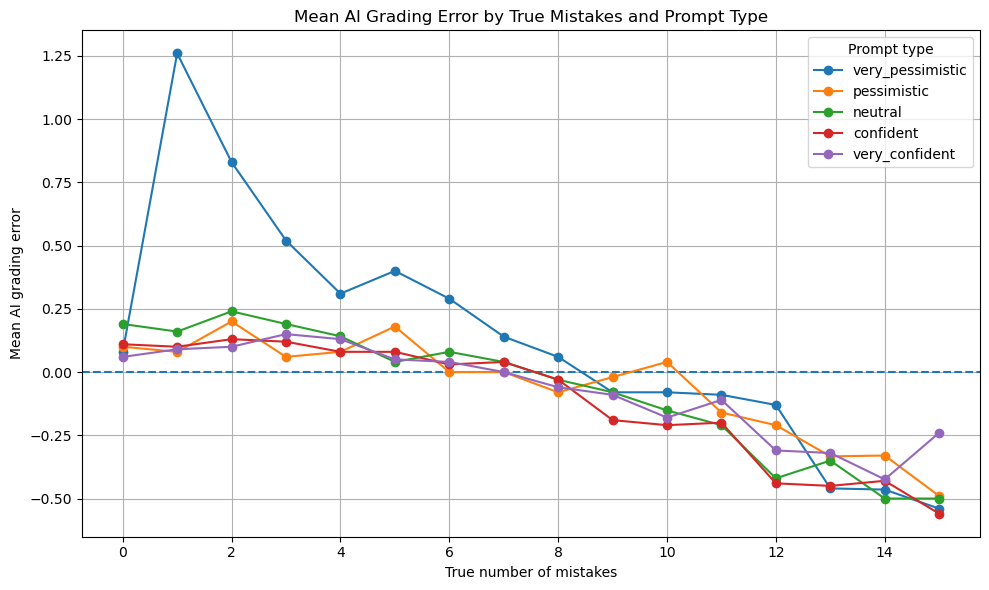

In [ ]:
mixed_anova = pg.mixed_anova(
    data=df,
    dv="ai_error",
    within="prompt_type",
    between="true_mistakes",
    subject="answer_key_id"
)

pg.print_table(mixed_anova)

# Plot mean AI error by true mistakes and prompt

summary = (
    df.groupby(["true_mistakes", "prompt_type"], observed=False)
    .agg(
        mean_ai_error=("ai_error", "mean"),
        sd_ai_error=("ai_error", "std"),
        n=("ai_error", "count")
    )
    .reset_index()
)

summary["se_ai_error"] = summary["sd_ai_error"] / np.sqrt(summary["n"])
summary["true_mistakes_numeric"] = summary["true_mistakes"].astype(int)

plt.figure(figsize=(10, 6))

for prompt in summary["prompt_type"].unique():
    subset = summary[summary["prompt_type"] == prompt]

    plt.errorbar(
        subset["true_mistakes_numeric"],
        subset["mean_ai_error"],
        marker="o",
        capsize=3,
        label=str(prompt)
    )
plt.axhline(0, linestyle="--")
plt.title("Mean AI grading error by true mistakes and prompt type")
plt.xlabel("True number of mistakes")
plt.ylabel("Mean AI grading error")
plt.legend(title="Prompt type")
plt.grid(True)
plt.tight_layout()
plt.show()


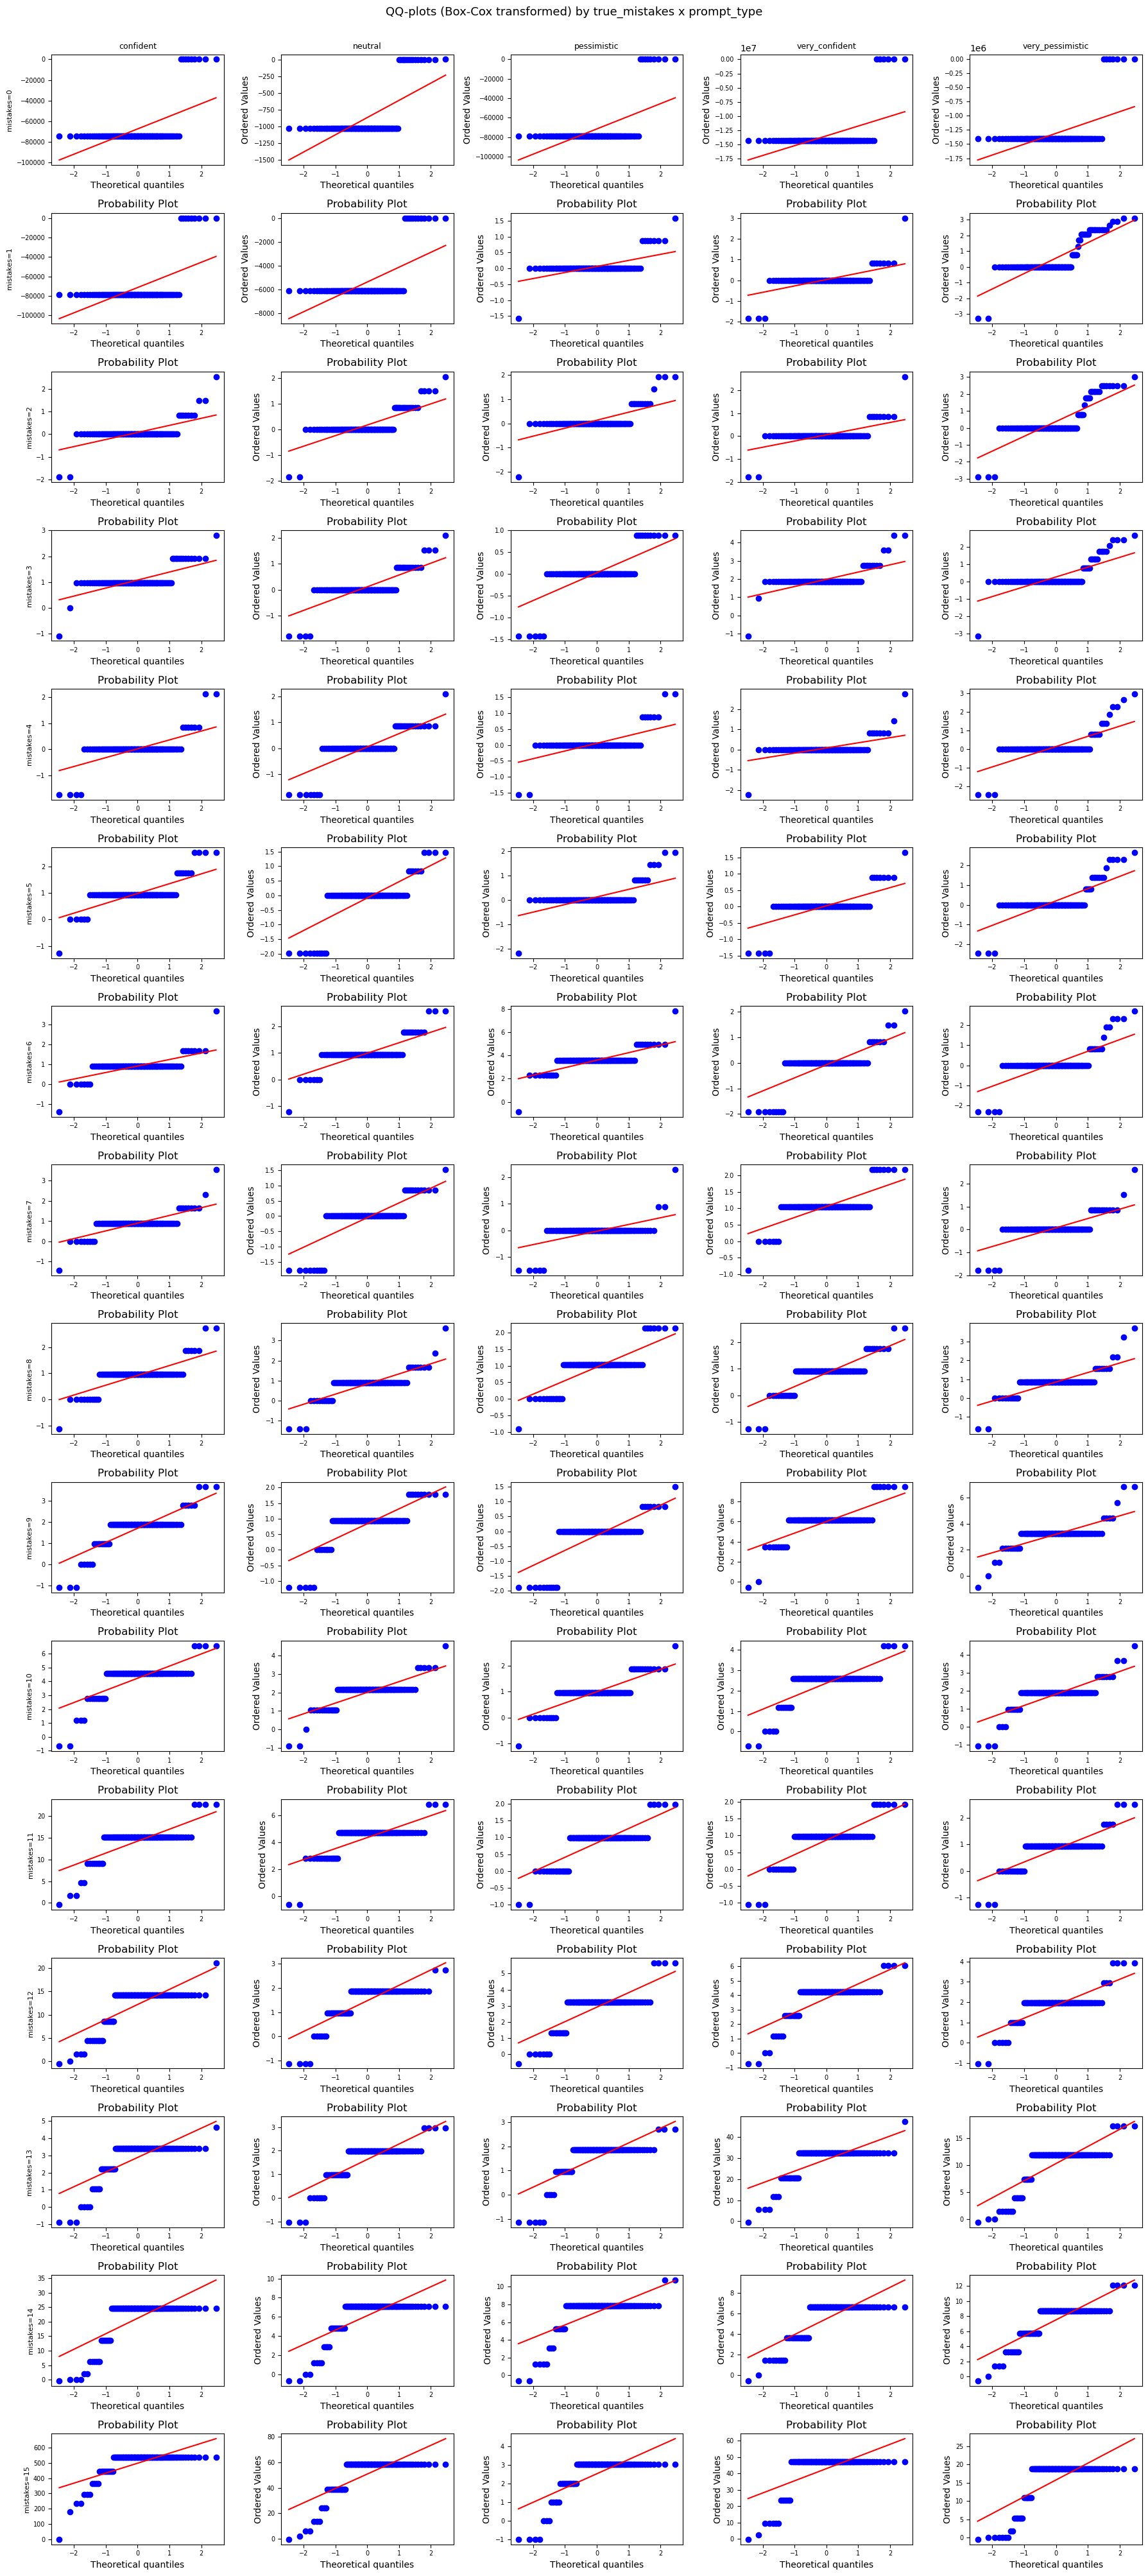

In [ ]:
matrix = df.groupby(["true_mistakes", "prompt_type"])["ai_error"].apply(np.array).unstack("prompt_type")

types = ["confident", "neutral", "pessimistic", "very_confident", "very_pessimistic"]
rows = matrix.index.tolist()  # expected 16 true_mistakes levels


def boxcox_residuals(x, eps=1e-6):
    x = np.asarray(x).ravel().astype(float)

    # Box-Cox requires strictly positive values; shift each vector if needed.
    shift = 1.0
    min_x = np.min(x)
    if min_x <= 0:
        shift = -min_x + eps

    x_pos = x + shift

    # Box-Cox also needs non-constant data.
    if np.allclose(x_pos, x_pos[0]):
        return None, np.nan, shift

    x_bc, lam = stats.boxcox(x_pos)
    return x_bc, lam, shift


fig, axes = plt.subplots(len(rows), len(types), figsize=(18, 40), squeeze=False)
lambda_table = {}

for r, tm in enumerate(rows):
    for c, prompt in enumerate(types):
        ax = axes[r, c]

        if prompt not in matrix.columns:
            ax.set_visible(False)
            continue

        res_raw = matrix.loc[tm, prompt]
        if not isinstance(res_raw, (np.ndarray, list, tuple)):
            ax.set_visible(False)
            continue

        res = np.asarray(res_raw).ravel()
        if res.size < 3:
            ax.set_visible(False)
            continue

        res_bc, lam, shift = boxcox_residuals(res)
        if res_bc is None:
            ax.set_visible(False)
            continue

        stats.probplot(res_bc, dist="norm", plot=ax)
        lambda_table[(tm, prompt)] = {"lambda": lam, "shift": shift}

        if r == 0:
            ax.set_title(prompt, fontsize=9)
        if c == 0:
            ax.set_ylabel(f"mistakes={tm}", fontsize=8)
        ax.tick_params(labelsize=7)

fig.suptitle("QQ-plots (Box-Cox transformed) by true_mistakes x prompt_type", y=1.002, fontsize=13)
plt.tight_layout()
plt.show()

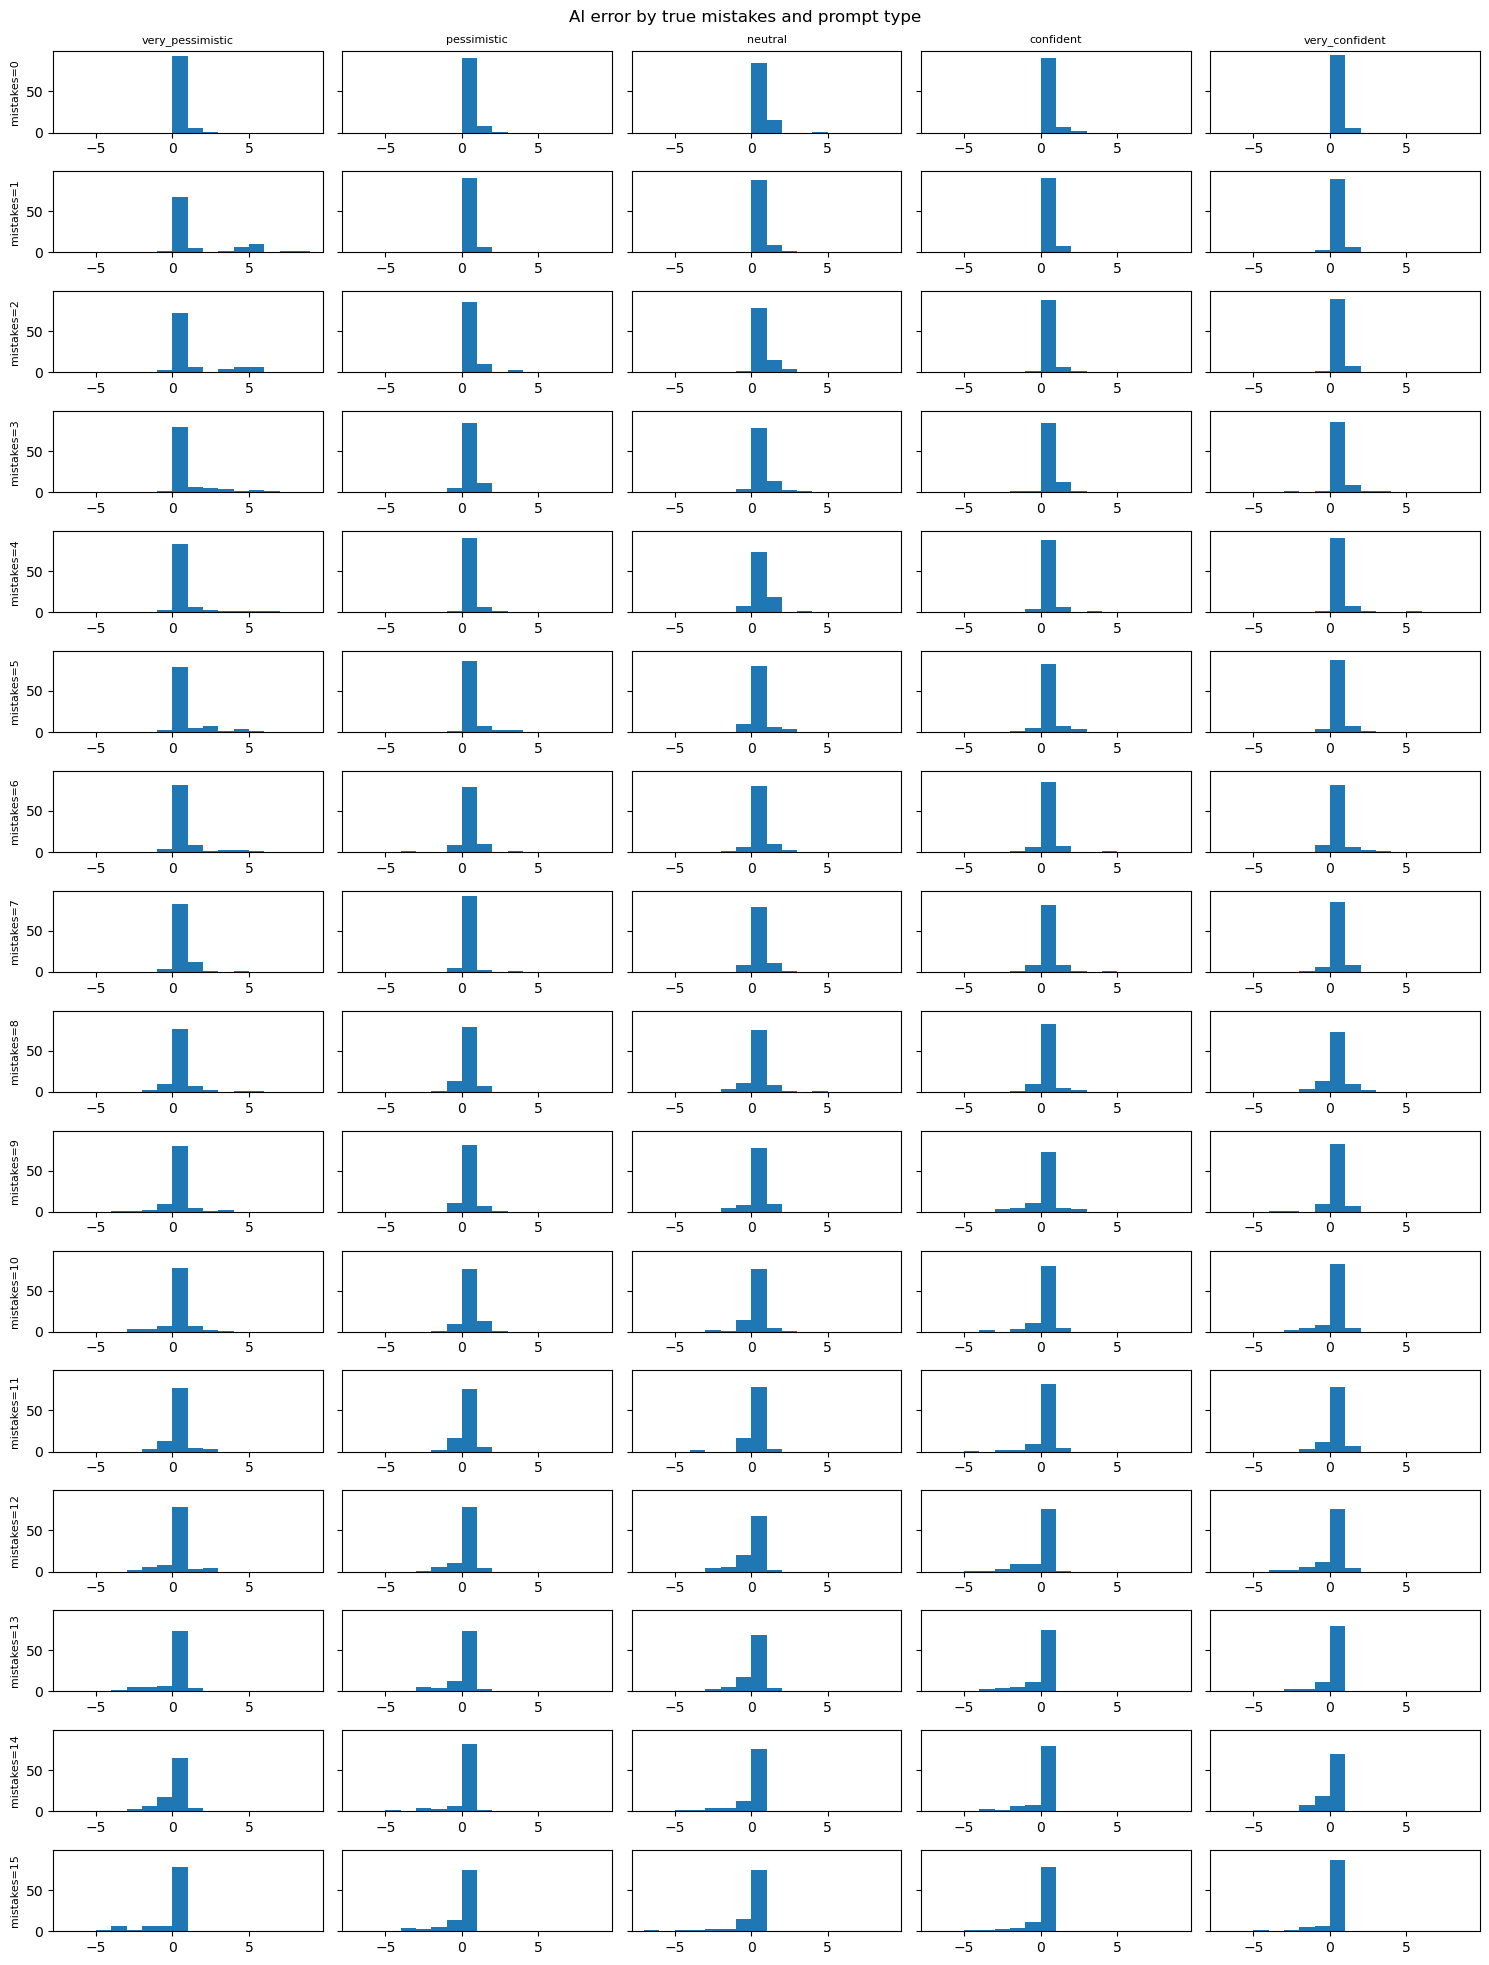

In [ ]:

all_data = [x for sublist in matrix.values.flatten() for x in sublist]
global_bins = np.arange(-7, max(all_data) + 2)

fig, axes = plt.subplots(len(matrix.index), len(matrix.columns), figsize=(15, 20), sharey=True)

for i, true_mistakes in enumerate(matrix.index):
    for j, prompt_type in enumerate(matrix.columns):
        ax = axes[i, j]
        data = matrix.loc[true_mistakes, prompt_type]
        ax.hist(data, bins=global_bins)
        if i == 0:
            ax.set_title(prompt_type, fontsize=8)
        if j == 0:
            ax.set_ylabel(f"mistakes={true_mistakes}", fontsize=8)

plt.suptitle("AI error by true mistakes and prompt type")
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

**ABSOLUTE ERROR VERSION**


ANOVA SUMMARY

Source             SS    DF1    DF2     MS       F    p_unc    p_GG_corr    np2      eps    sphericity    W_spher    p_spher
-------------  ------  -----  -----  -----  ------  -------  -----------  -----  -------  ------------  ---------  ---------
true_mistakes  26.482     15   1107  1.765   4.121    0.000      nan      0.053  nan           nan        nan        nan
prompt_type    29.130      4   4428  7.282  16.871    0.000        0.000  0.015    0.814         0.000      0.687      0.000
Interaction    43.774     60   4428  0.730   1.690    0.001      nan      0.022  nan           nan        nan        nan



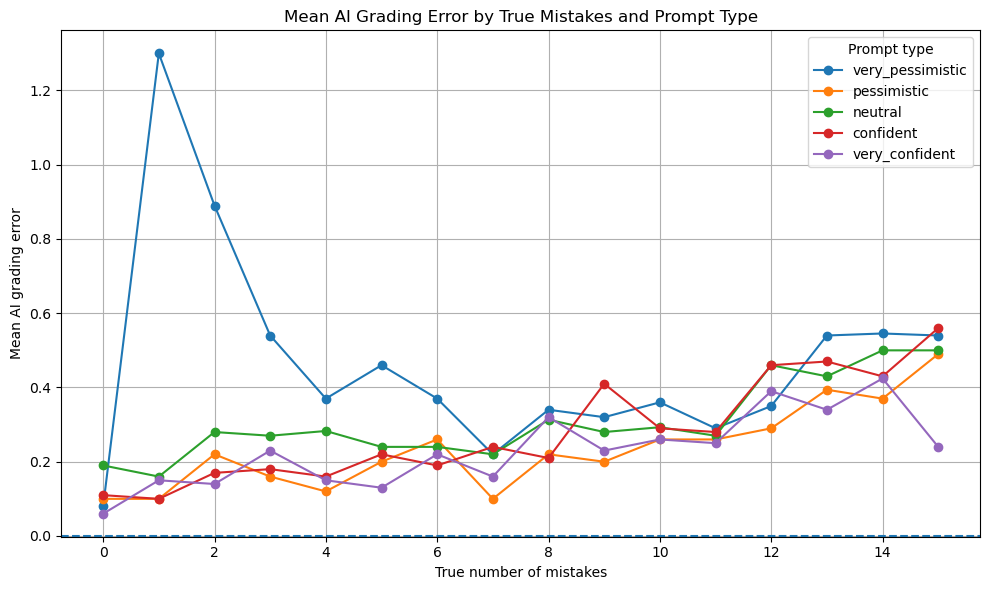

In [ ]:
mixed_anova = pg.mixed_anova(
    data=df,
    dv="Absolute_error",
    within="prompt_type",
    between="true_mistakes",
    subject="answer_key_id"
)

pg.print_table(mixed_anova)

# Plot mean AI error by true mistakes and prompt

summary = (
    df.groupby(["true_mistakes", "prompt_type"], observed=False)
    .agg(
        mean_ai_error=("Absolute_error", "mean"),
        sd_ai_error=("Absolute_error", "std"),
        n=("Absolute_error", "count")
    )
    .reset_index()
)

summary["se_ai_error"] = summary["sd_ai_error"] / np.sqrt(summary["n"])
summary["ci95"] = 1.96 * summary["se_ai_error"]
summary["true_mistakes_numeric"] = summary["true_mistakes"].astype(int)

plt.figure(figsize=(10, 6))

for prompt in summary["prompt_type"].unique():
    subset = summary[summary["prompt_type"] == prompt]

    plt.errorbar(
        subset["true_mistakes_numeric"],
        subset["mean_ai_error"],
        marker="o",
        capsize=3,
        label=str(prompt)
    )

plt.axhline(0, linestyle="--")
plt.title("Mean AI grading error by true mistakes and prompt type")
plt.xlabel("True number of mistakes")
plt.ylabel("Mean AI grading error")
plt.legend(title="Prompt type")
plt.grid(True)
plt.tight_layout()
plt.show()

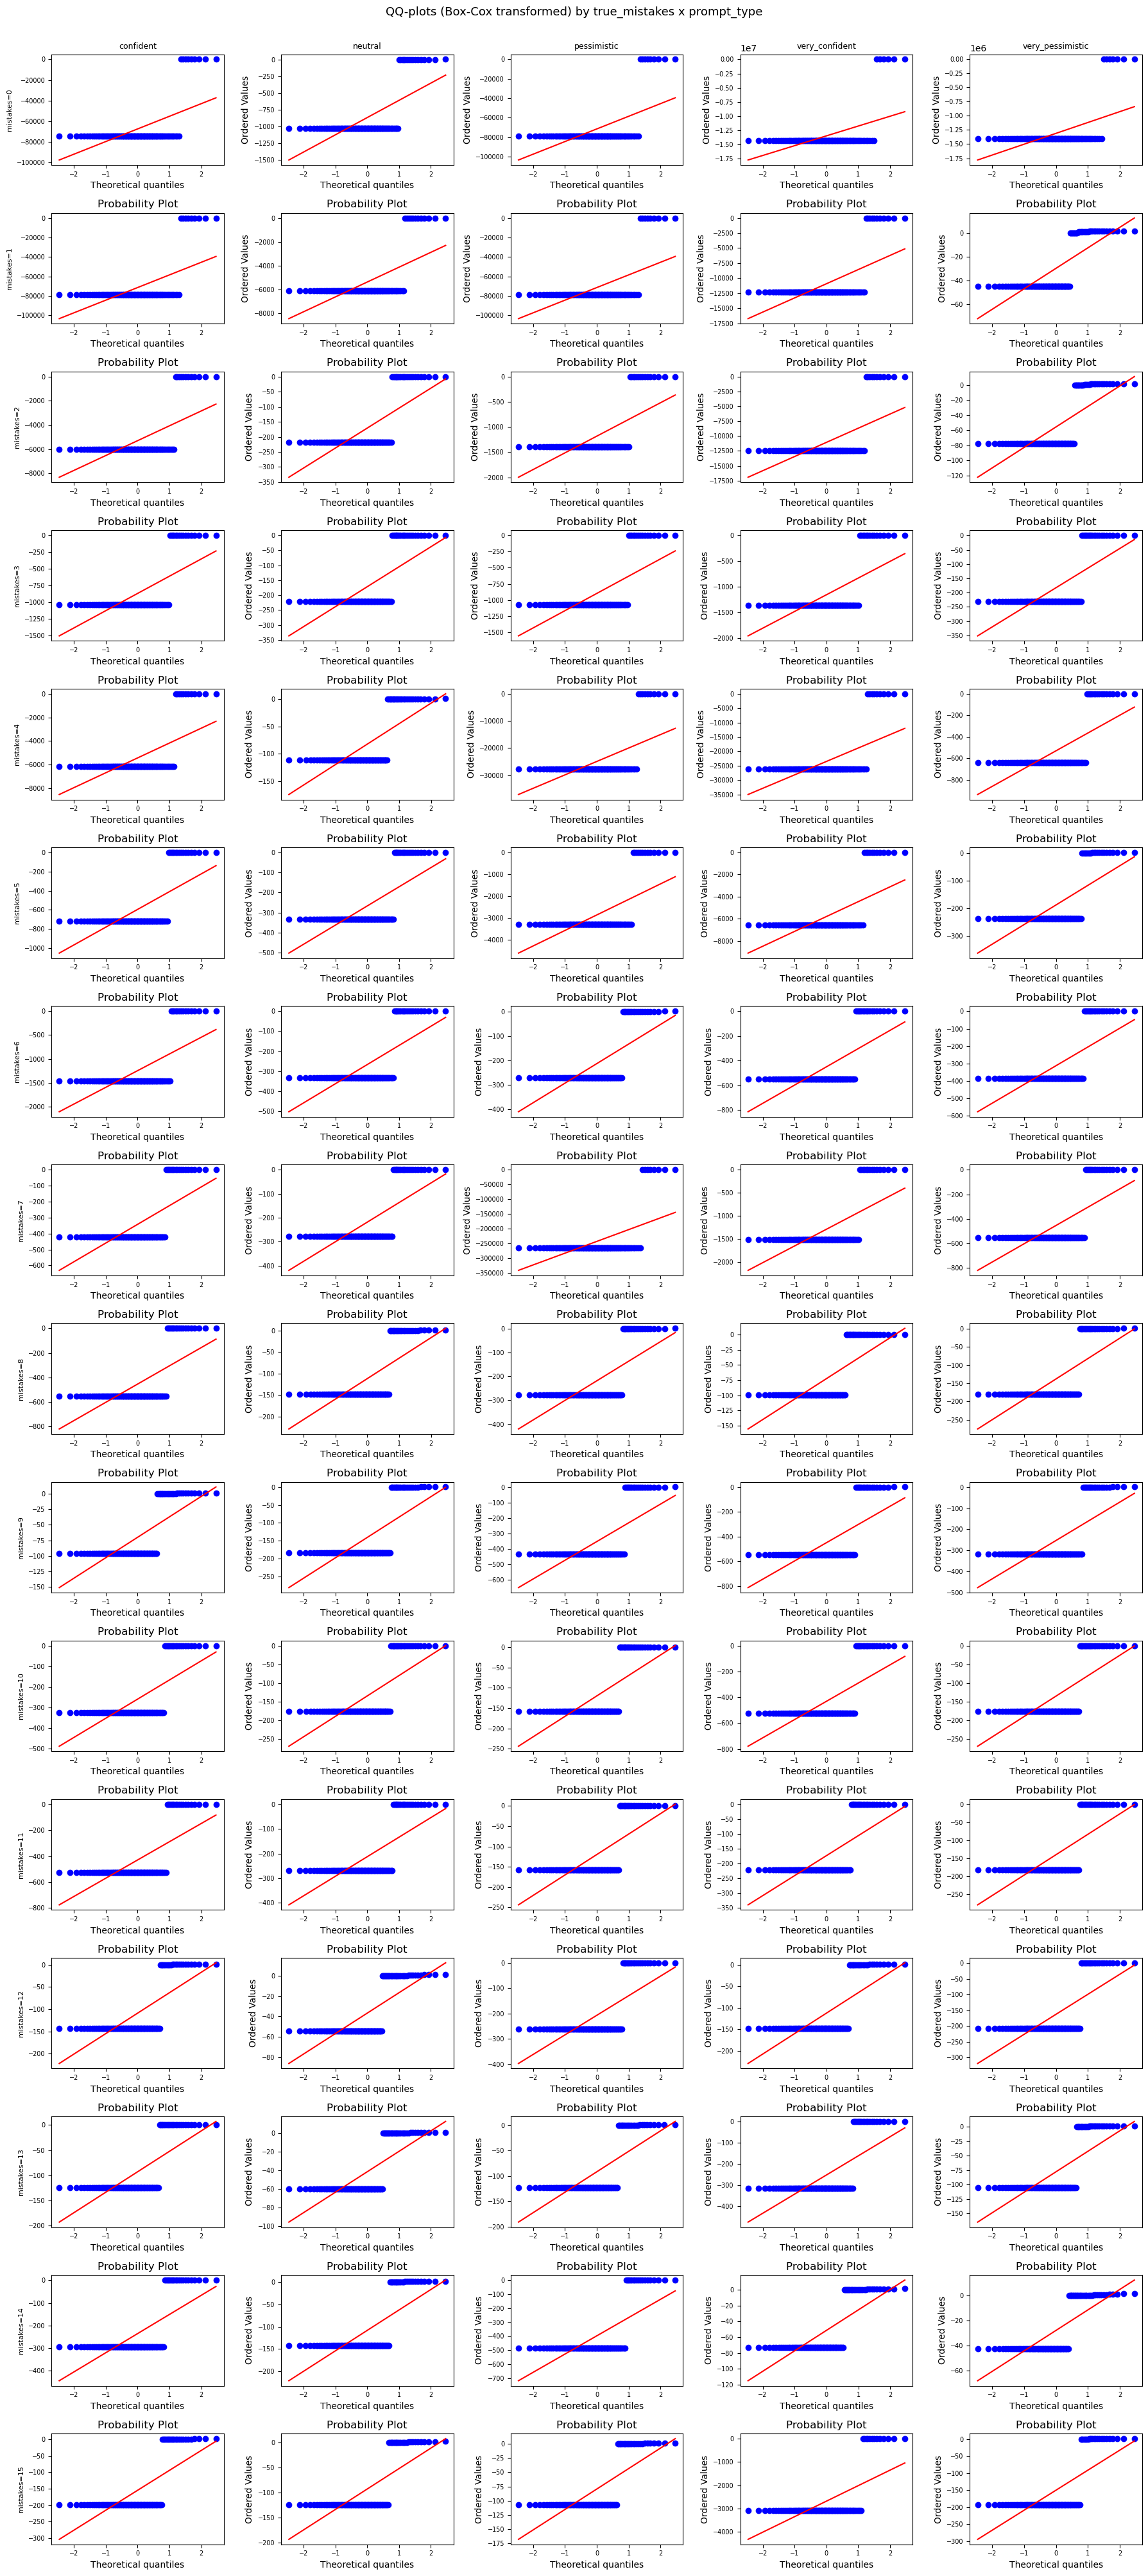

In [ ]:
matrix = df.groupby(["true_mistakes", "prompt_type"])["Absolute_error"].apply(np.array).unstack("prompt_type")

types = ["confident", "neutral", "pessimistic", "very_confident", "very_pessimistic"]
rows = matrix.index.tolist()  # expected 16 true_mistakes levels


def boxcox_residuals(x, eps=1e-6):
    x = np.asarray(x).ravel().astype(float)

    # Box-Cox requires strictly positive values; shift each vector if needed.
    shift = 1.0
    min_x = np.min(x)
    if min_x <= 0:
        shift = -min_x + eps

    x_pos = x + shift

    # Box-Cox also needs non-constant data.
    if np.allclose(x_pos, x_pos[0]):
        return None, np.nan, shift

    x_bc, lam = stats.boxcox(x_pos)
    return x_bc, lam, shift


fig, axes = plt.subplots(len(rows), len(types), figsize=(18, 40), squeeze=False)
lambda_table = {}

for r, tm in enumerate(rows):
    for c, prompt in enumerate(types):
        ax = axes[r, c]

        if prompt not in matrix.columns:
            ax.set_visible(False)
            continue

        res_raw = matrix.loc[tm, prompt]
        if not isinstance(res_raw, (np.ndarray, list, tuple)):
            ax.set_visible(False)
            continue

        res = np.asarray(res_raw).ravel()
        if res.size < 3:
            ax.set_visible(False)
            continue

        res_bc, lam, shift = boxcox_residuals(res)
        if res_bc is None:
            ax.set_visible(False)
            continue

        stats.probplot(res_bc, dist="norm", plot=ax)
        lambda_table[(tm, prompt)] = {"lambda": lam, "shift": shift}

        if r == 0:
            ax.set_title(prompt, fontsize=9)
        if c == 0:
            ax.set_ylabel(f"mistakes={tm}", fontsize=8)
        ax.tick_params(labelsize=7)

fig.suptitle("QQ-plots (Box-Cox transformed) by true_mistakes x prompt_type", y=1.002, fontsize=13)
plt.tight_layout()
plt.show()

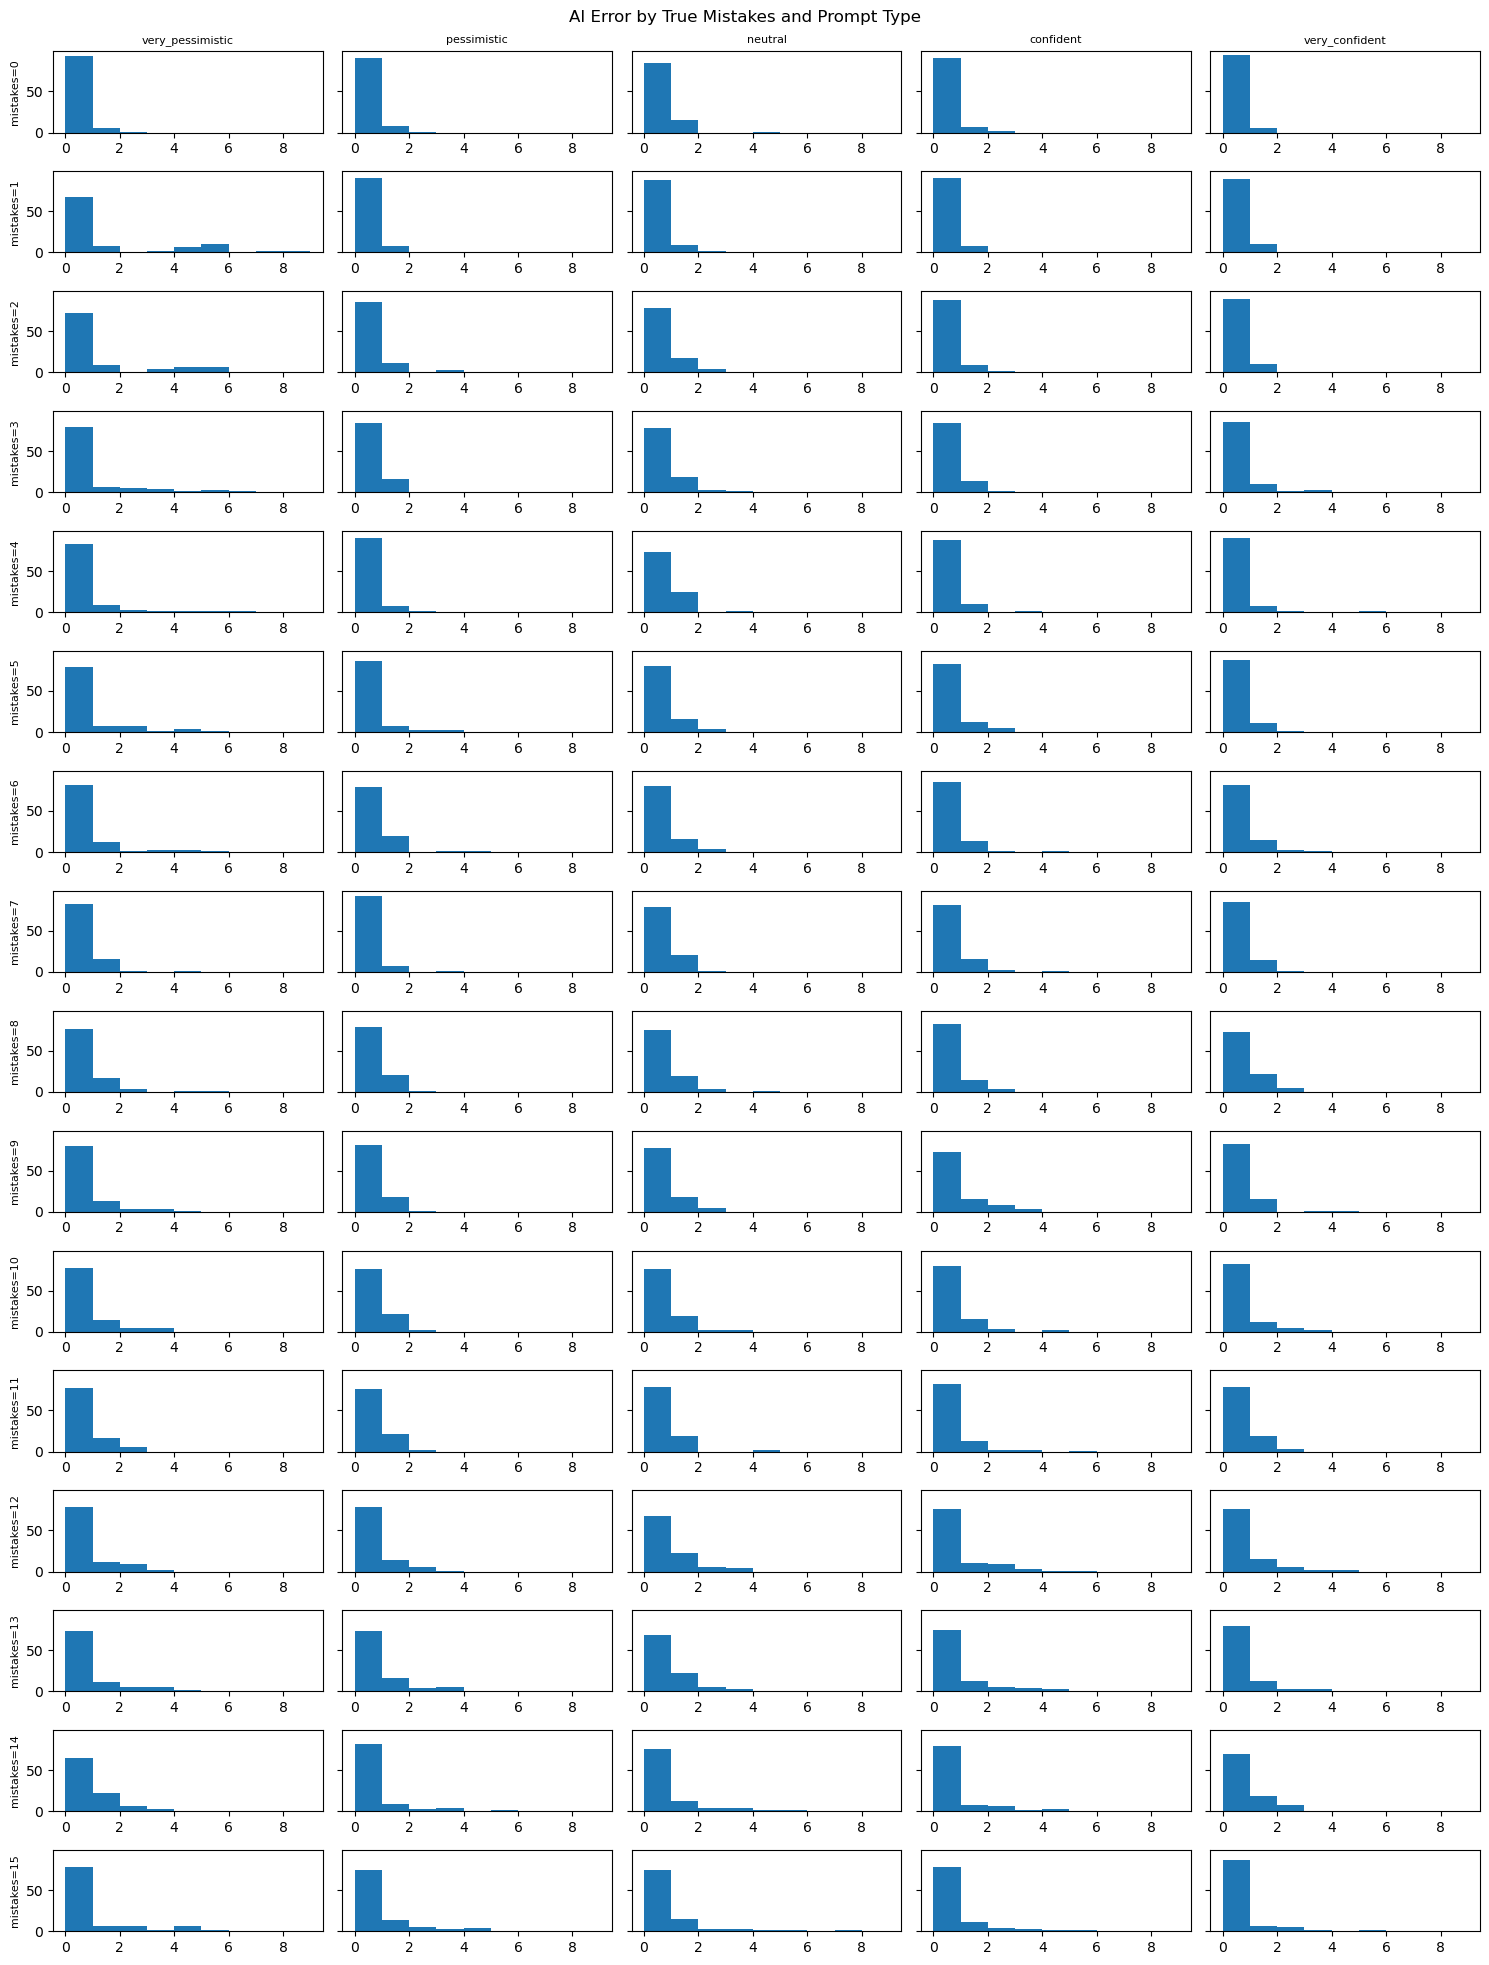

In [ ]:
all_data = [x for sublist in matrix.values.flatten() for x in sublist]
global_bins = np.arange(min(all_data), 10)

fig, axes = plt.subplots(len(matrix.index), len(matrix.columns), figsize=(15, 20), sharey=True)

for i, true_mistakes in enumerate(matrix.index):
    for j, prompt_type in enumerate(matrix.columns):
        ax = axes[i, j]
        data = matrix.loc[true_mistakes, prompt_type]
        ax.hist(data, bins=global_bins)
        if i == 0:
            ax.set_title(prompt_type, fontsize=8)
        if j == 0:
            ax.set_ylabel(f"mistakes={true_mistakes}", fontsize=8)

plt.suptitle("AI Error by True Mistakes and Prompt Type")
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

Ikke normal fordelt så vi bruger ART

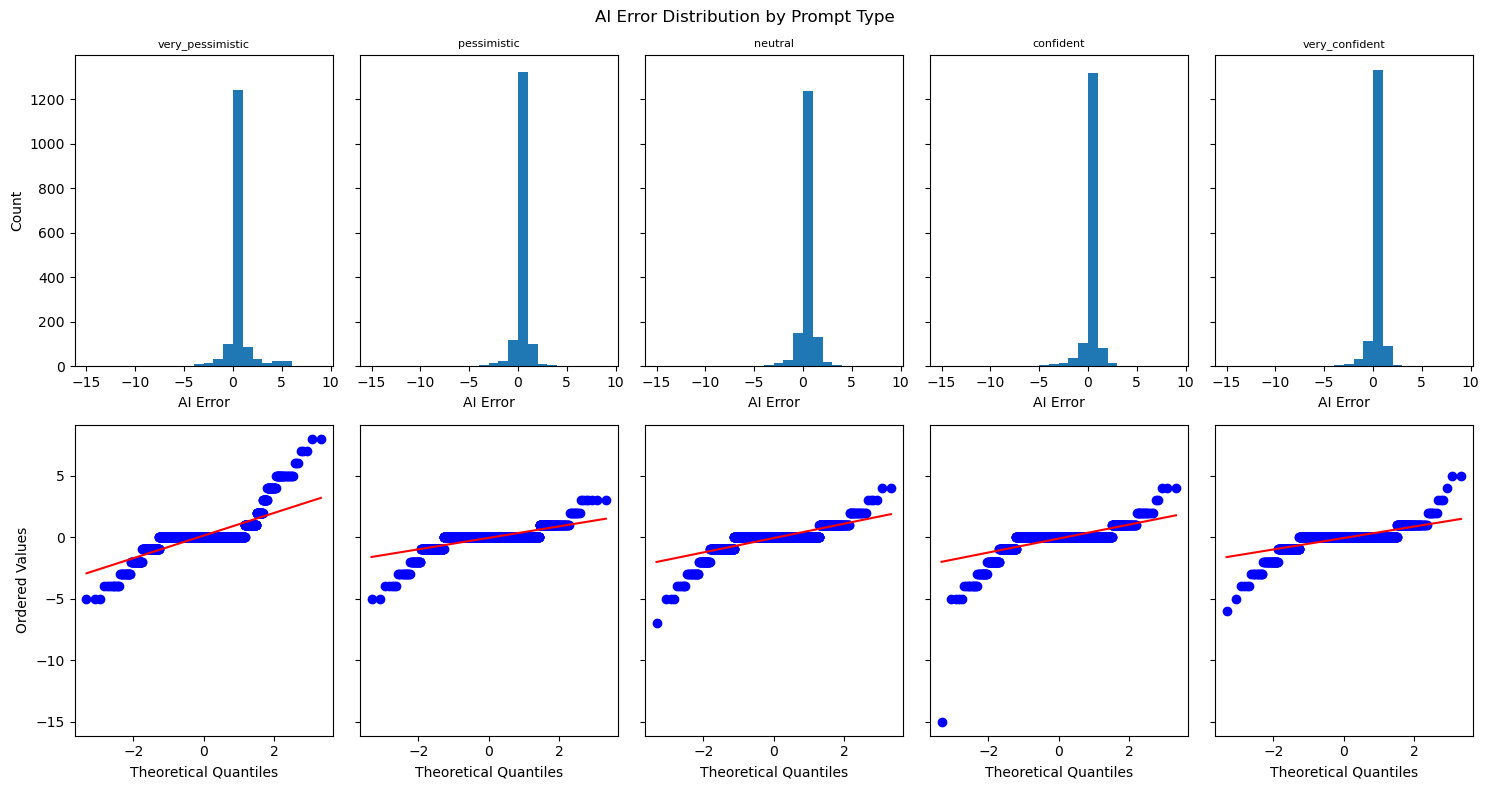

In [ ]:
error_by_prompt = df.groupby("prompt_type", observed=True)["ai_error"].apply(list)

prompt_types = error_by_prompt.index.tolist()

all_data = [x for sublist in error_by_prompt.values for x in sublist]
global_bins = np.arange(min(all_data), max(all_data) + 2)

fig, axes = plt.subplots(2, len(prompt_types), figsize=(15, 8), sharey="row")

for j, prompt_type in enumerate(prompt_types):
    # Row 1: histograms
    ax = axes[0, j]
    ax.hist(error_by_prompt[prompt_type], bins=global_bins)
    ax.set_title(prompt_type, fontsize=8)
    if j == 0:
        ax.set_ylabel("Count")
    ax.set_xlabel("AI Error")

    # Row 2: QQ plots
    ax = axes[1, j]
    from scipy import stats
    stats.probplot(error_by_prompt[prompt_type], dist="norm", plot=ax)
    ax.set_title("")  # remove redundant title
    if j != 0:
        ax.set_ylabel("")
    ax.set_xlabel("Theoretical Quantiles")

plt.suptitle("AI Error Distribution by Prompt Type")
plt.tight_layout()
plt.show()

In [ ]:
rm_anova = pg.rm_anova(
    data=df,
    dv="ai_error",
    within="prompt_type",
    subject="answer_key_id",
    detailed=True
)
print(rm_anova)

        Source           SS    DF        MS          F         p_unc  \
0  prompt_type    32.190386     4  8.047597  17.104925  6.240846e-14   
1        Error  2111.533038  4488  0.470484        NaN           NaN   

      p_GG_corr       ng2       eps sphericity  W_spher       p_spher  
0  9.265468e-12  0.010988  0.813207      False  0.68438  6.610366e-86  
1           NaN       NaN       NaN        NaN      NaN           NaN  
